## 1 概述

前面已经学习了线性回归、逻辑回归和 Softmax 回归，它们本质上都属于线性模型，可以统一概括为：
$$
\text{预测} = \text{激活函数}(XW + b)
$$

- 线性回归：无激活函数，直接输出连续值。
- 逻辑回归：激活函数是 Sigmoid，输出 0~1 概率，用于二分类。
- Softmax 回归：激活函数是 Softmax ，输出概率向量，用于多分类。

这三者都仅包含一个线性层（即输入直接连接到输出），所以它们能解决的问题仅限于线性可分的数据。然而现实中的数据往往是非线性可分的，比如图像分类、语音识别。单层模型无法拟合复杂的决策边界，因此需要引入多个线性层，并在层间加入非线性激活函数（如 ReLU ），使模型具备拟合任意复杂函数的能力（通用近似定理）。

这就是基本的神经网络 **MLP（多层感知机，Multilayer Perceptron）** 的核心思想：通过多个线性变换和非线性激活的堆叠，将原始输入逐步映射到特征空间，最终输出预测结果。

不同于单层的“输入特征”直接到“输出预测”，这种多层的结构，数据在训练时需要一个层与层之间的传播，于是有了前向传播和反向传播的概念：
- 前向传播：输入特征 $X$ 依次穿过各个隐藏层，最终转化为预测值 $\hat{Y}$ 。
- 反向传播：将预测误差 $\hat{Y}-Y$ 从最后面的输出层开始，反向沿着各个隐藏层向前传递，并据此计算出每一层的梯度，从而指导模型参数的更新。

## 2 前向传播

> 假设是两层隐藏层的 MLP

|层名|输入|线性部分|输出|备注|
|-|-|-|-|-|
|输入层|||$X_1$|形状：批次数量 $\times$ 特征数量|
|隐藏层 1 |$X_1$|$Z_1=X_1W_1+b_1$|$X_2=\text{ReLU}(Z_1)$||
|隐藏层 2 |$X_2$|$Z_2=X_2W_2+b_2$|$X_3=\text{ReLU}(Z_2)$||
|输出层 |$X_3$|$Z_3=X_3W_3+b_3$|$\hat{Y}=\text{Sigmoid}(Z_3)$||

激活函数 ReLU 实际是个分段函数 $X=\text{ReLU}(Z)=\max(0,Z)$ ，假设 $z$ 是 $Z$ 中的元素：
- 当 $z>0$ 时，结果是本身 $z$ ，对应神经元激活。
- 当 $z<=0$ 时，结果为 $0$ ，对应神经元死亡。

下文反向传播时，需要对 ReLU 函数求导：
- 当 $z>0$ 时，$X_3=z$ ，求导是 1 。
- 当 $z<0$ 时，$X_3=0$ ，求导是 0 。
- 当 $z=0$ 时，因为左右极限不相等所以不可导，为了工程实践，约定导数也为 0 。

## 3 反向传播

> 反向传播的是误差

|层名|误差|权重梯度|偏置梯度|备注|
|-|-|-|-|-|
|输出层|$\delta_3=\hat{Y}-Y$|$dW_3=X_3^T\cdot\delta_3$|$db_3=\sum\delta_3^i$||
|隐藏层 2 |$\delta_2=(\delta_3\cdot W_3^T)\odot 1_{z_2>0}$|$dW_2=X_2^T\cdot\delta_2$|$db_2=\sum\delta_2^i$||
|隐藏层 1 |$\delta_1=(\delta_2\cdot W_2^T)\odot 1_{z_1>0}$|$dW_1=X_1^T\cdot\delta_1$|$db_1=\sum\delta_1^i$||

<br>

- 在 MLR 和 LR 中推导过：
    - 求梯度：$\frac{\partial J}{\partial W}=X^T(\hat{Y}-Y)$
    - 求误差：$\frac{\partial J}{\partial Z}=\hat{Y}-Y$
- 使 $\delta_3=\hat{Y}-Y$ ，那么输出层首次计算误差很容易理解：$dW_3=\frac{\partial J}{\partial W_3}=X_3^T\cdot\delta_3$
- 反向传播到隐藏层第二层：
    - 求误差：$\delta_2=\frac{\partial J}{\partial Z_2}$ ，看前向传播可知，要用 $Z_2$ 先算出 $X_3$ ，再以 $X_3$ 为输入才算出 J ，所以 $\frac{\partial J}{\partial Z_2}=\frac{\partial J}{\partial X_3}\cdot \frac{\partial X_3}{\partial Z_2}$
        - $\frac{\partial J}{\partial X_3}=\frac{\partial J}{\partial Z_3}\cdot \frac{\partial Z_3}{\partial X_3}=\delta_3\cdot(X_3W_3+b_3)_{X_3}^{'}=\delta_3\cdot W_3^T$ （取 $W_3$ 的转置是为了维度匹配）
        - 已知 $X_3=\text{ReLU}(Z_2)$ ，对于 $\frac{\partial X_3}{\partial Z_2}$ 就是上文的 ReLU 函数求导，即：$\frac{\partial X_3}{\partial Z_2}=1_{z_2>0}$
        - 因此：$\delta_2=(\delta_3\cdot W_3^T)\odot 1_{z_2>0}$
    - 求梯度：$dW_2=\frac{\partial J}{\partial W_2}=X_2^T\cdot\delta_2$
- 反向传播到隐藏层第一层是一样的原理，这是一个递归的过程。

> $1_{z>0}$ 表示一个矩阵，它的元素与矩阵 $Z\{z_i\}$ 一一对应，当 $z_i>0$ 对应位置是 $1$ ，当 $z_i<=0$ 对应位置是 $0$ 。  
> $A \odot 1_{z>0}$ 表示对矩阵 A 与 矩阵 $1_{z>0}$ 逐元素相乘，也叫进行 ReLU 修正，效果是：$A$ 中元素，若在 $1_{z>0}$ 中对应位置为 $1$ ，想乘保留原元素的值，若在 $1_{z>0}$ 中对应位置为 $0$ ，想乘则为 $0$ 。
> 直观理解 ReLU 修正：就是让前向传播时死亡的神经元的误差不进行反向传播。

最后是偏置梯度 $db$ 的推导，以输出层为例：$Z_3=x_3W_3+b_3$ ，那么 
$$
db_3=\frac{\partial J}{\partial b_3}=\frac{\partial J}{\partial Z_3}\cdot\frac{\partial Z_3}{\partial b_3}=\delta_3\cdot 1=\delta_3
$$
因为偏置 $b_3$ 在计算时会被广播到批次中的每一个样本，所以在反向传播时，我们需要把批次维度上的误差累加或平均，为简介这里用累加：$db_3=\sum\delta_3^i$


## 4 手写代码

在理解了数学推导后，我们可以用一个小型神经网络在 XOR（异或）问题上进行验证。

XOR（异或）问题是经典的非线性可分示例。其四个输入点 $ (0,0)、(0,1)、(1,0)、(1,1) $ 分别对应输出 $ 0、1、1、0 $ 。

在二维平面上，这两类点分别位于对角线的两端：
- `0` 类在左下和右上
- `1` 类在左上和右下

无论怎么画，都无法用一条直线（即单个线性层）将这两类点完全分开。这就是单层线性模型的局限所在。

而加入一个隐藏层后，网络可以将原始输入空间映射到新的特征空间，使得原本线性不可分的数据在新空间中变得线性可分。

下面的代码将训练一个单隐藏层 MLP 来解决 XOR 问题：


In [2]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# 网络结构：输入层(2) → 隐藏层(16) → 输出层(1)
hidden_size = 16
lr = 0.1
epochs = 20000
m = 4  # 批次大小（样本总数）

np.random.seed(0)
W1 = np.random.randn(2, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W3 = np.random.randn(hidden_size, 1) * 0.5
b3 = np.zeros((1, 1))

# XOR 数据集
X1 = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [1], [1], [0]])

for epoch in range(epochs):
    # ---------- 前向传播 ----------
    Z1 = X1 @ W1 + b1                # 隐藏层线性部分
    X2 = relu(Z1)                    # 隐藏层激活输出（ReLU）
    Z3 = X2 @ W3 + b3                # 输出层线性部分
    Y_hat = sigmoid(Z3)              # 最终预测

    # 损失（二元交叉熵，平均）
    loss = -np.mean(Y * np.log(Y_hat + 1e-8) + (1 - Y) * np.log(1 - Y_hat + 1e-8))

    # ---------- 反向传播 ----------
    dZ3 = Y_hat - Y                                  # 输出层误差 δ3
    dW3 = (X2.T @ dZ3) / m                           # 输出层权重梯度
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m     # 输出层偏置梯度

    dX2 = dZ3 @ W3.T                                 # 误差传回隐藏层激活前
    dZ1 = dX2 * relu_derivative(Z1)                  # 隐藏层误差 δ1（含 ReLU 修正）
    dW1 = (X1.T @ dZ1) / m                           # 隐藏层权重梯度
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m     # 隐藏层偏置梯度

    # ---------- 参数更新 ----------
    W3 -= lr * dW3
    b3 -= lr * db3
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 2000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

print("\n预测结果（四舍五入后）：")
print(np.round(Y_hat))
# 期望输出 [[0.], [1.], [1.], [0.]]

Epoch 0, Loss: 0.731607
Epoch 2000, Loss: 0.009623
Epoch 4000, Loss: 0.004284
Epoch 6000, Loss: 0.002713
Epoch 8000, Loss: 0.001973
Epoch 10000, Loss: 0.001547
Epoch 12000, Loss: 0.001270
Epoch 14000, Loss: 0.001075
Epoch 16000, Loss: 0.000932
Epoch 18000, Loss: 0.000822

预测结果（四舍五入后）：
[[0.]
 [1.]
 [1.]
 [0.]]


可以直观理解为用能拐弯的折线进行了划分，每个 ReLU 神经元都会在决策边界上增加一个“折弯点”。在一个隐藏层中，多个神经元各自产生一条折线，共同围成最终的决策区域。堆叠更多隐藏层，则是将这些基础的折线逐层组合，最终形成极其复杂的非线性边界。

下面代码将画出“拐弯的折线”是怎么进行二分类的：

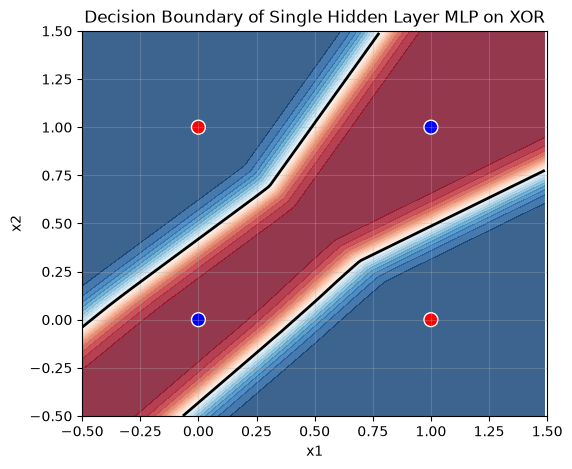

In [3]:
# 可视化决策边界（单隐藏层 MLP 在 XOR 问题上的表现）
import matplotlib.pyplot as plt

def plot_decision_boundary(X1, Y, model_weights, hidden_size=16):
    """
    绘制 MLP 在二维输入空间上的决策边界。
    model_weights: 包含 W1, b1, W3, b3 的元组
    """
    W1, b1, W3, b3 = model_weights

    # 生成网格点
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # 前向传播
    Z1_grid = grid @ W1 + b1
    A1_grid = relu(Z1_grid)
    Z3_grid = A1_grid @ W3 + b3
    Y_hat_grid = sigmoid(Z3_grid)
    Y_hat_grid = Y_hat_grid.reshape(xx.shape)

    # 绘制预测概率等高线
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Y_hat_grid, levels=20, cmap='RdBu', alpha=0.8)
    # 添加决策边界线（0.5概率线）
    plt.contour(xx, yy, Y_hat_grid, levels=[0.5], colors='black', linewidths=2)

    # 绘制原始数据点
    colors = ['blue' if y == 0 else 'red' for y in Y.flatten()]
    plt.scatter(X1[:,0], X1[:,1], c=colors, edgecolors='white', s=100)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Decision Boundary of Single Hidden Layer MLP on XOR')
    plt.grid(alpha=0.3)
    plt.show()

# 调用绘图函数
plot_decision_boundary(X1, Y, (W1, b1, W3, b3), hidden_size)